In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
import utils.helpers as utils_helpers
from sklearn.metrics import r2_score
import json
from pathlib import Path

In [2]:
model_conc_absmax = xgb.Booster()
model_conc_absmax.load_model(Path("..") / "data" / "models" / "FCKcat.json")
df_test_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_test_pairs.pkl")
df_train_pairs = pd.read_pickle(Path("..") / "data" / "datasets" / "df_train_pairs.pkl")

In [3]:
# loading mapping dictionaries:
with open(Path("..") / "data" / "mapping" / "dict_index_to_sequence.json", 'r') as f:
    index_to_sequence = json.load(f)

with open(Path("..") / "data" / "mapping" / "dict_index_to_esm2_absmaxpooling.json", 'r') as f:
    index_to_esm2_absmaxpooling = json.load(f)

In [4]:
df_test_pairs = utils_helpers.add_esm2_absmax(df_test_pairs, index_to_esm2_absmaxpooling)
df_test_pairs = utils_helpers.prepro_v2(df_test_pairs)

In [5]:
test_X = np.array(list(df_test_pairs["sequences_representation"]))
test_Y = np.array(list(df_test_pairs["delta_log_kcat"]))

dtest = xgb.DMatrix(test_X)  
predictions = model_conc_absmax.predict(dtest)

r2= r2_score(test_Y, predictions)

print(f"R2 Score validation : {r2}")
df_test_pairs['delta_log_kcat_predicted'] = predictions

R2 Score validation : 0.44460947709396237


In [6]:
df_test_unpaired = utils_helpers.unpack_pairs_df(df_test_pairs)
df_train_unpaired = utils_helpers.unpack_pairs_df(df_train_pairs)

In [7]:

df_mutant_kcat = pd.DataFrame(columns=['Identifier', 'index', 'log10kcat'])
df_wildtype_kcat_test = pd.DataFrame(columns=['Identifier', 'index', 'log10kcat'])
for ind in df_test_pairs.index:
    type_list = df_test_pairs.loc[ind, 'Type']
    identifier = df_test_pairs.loc[ind, 'Identifier']
    ind1, ind2 = df_test_pairs.loc[ind, 'index']
    log10kcat1, log10kcat2 = df_test_pairs.loc[ind, 'log10kcat']

    if type_list == ["mutant", "mutant"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)

    elif type_list == ["wildtype", "mutant"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)
        df_wildtype_kcat_test = pd.concat([
            df_wildtype_kcat_test,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
        ], ignore_index=True)

    elif type_list == ["mutant", "wildtype"]:
        df_mutant_kcat = pd.concat([
            df_mutant_kcat,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind1], 'log10kcat': [log10kcat1]}),
        ], ignore_index=True)
        df_wildtype_kcat_test = pd.concat([
            df_wildtype_kcat_test,
            pd.DataFrame({'Identifier': [identifier], 'index': [ind2], 'log10kcat': [log10kcat2]}),
        ], ignore_index=True)
# remove duplicates
df_mutant_kcat = df_mutant_kcat.drop_duplicates().reset_index(drop=True)

In [8]:
df_mutant_kcat['predicted_log10kcat'] = np.nan
df_mutant_kcat['collective_pred'] = np.nan
for idx, row in df_mutant_kcat.iterrows():
    identifier = row['Identifier']
    index = row['index']
    df_temp = df_train_unpaired[df_train_unpaired['Identifier'] == identifier]

    if df_temp.empty:

        df_temp_wt = df_wildtype_kcat_test[df_wildtype_kcat_test['Identifier'] == identifier]
        kcat_wt = df_temp_wt['log10kcat'].values[0] if not df_temp_wt.empty else None
        index_wt = df_temp_wt['index'].values[0] if not df_temp_wt.empty else None

        esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_wt)] if index_wt is not None else None
        esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)]
        concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None

        input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
        dinput = xgb.DMatrix(input_vector_absmax) 
        delta_pred = model_conc_absmax.predict(dinput)[0] 

        pred = kcat_wt - delta_pred if kcat_wt is not None else None

        df_mutant_kcat.at[idx, 'predicted_log10kcat'] = pred
        df_mutant_kcat.at[idx, 'collective_pred'] = pred

    else:
        df_temp_wt = df_temp[df_temp['Type'] == 'wildtype']
        if not df_temp_wt.empty:
            
            kcat_wt = df_temp_wt['log10kcat'].values[0] if not df_temp_wt.empty else None
            index_wt = df_temp_wt['index'].values[0] if not df_temp_wt.empty else None


            esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_wt)] if index_wt is not None else None
            esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)]
            concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None


            input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
            dinput = xgb.DMatrix(input_vector_absmax)

            delta_pred = model_conc_absmax.predict(dinput)[0] 
            df_mutant_kcat.at[idx, 'predicted_log10kcat'] = kcat_wt - delta_pred if kcat_wt is not None else None



        kcats_predictions= []
        for ind in df_temp.index:
            kcat_i = df_temp.loc[ind, 'log10kcat']
            index_i = df_temp.loc[ind, 'index']

            esm2_absmax_1 = index_to_esm2_absmaxpooling[str(index_i)] if index_i is not None else None
            esm2_absmax_2 = index_to_esm2_absmaxpooling[str(index)] if index is not None else None
            concat_absmax = np.concatenate((esm2_absmax_1, esm2_absmax_2)) if esm2_absmax_1 is not None else None



            input_vector_absmax = concat_absmax.reshape(1, -1) if concat_absmax is not None else None
            dinput = xgb.DMatrix(input_vector_absmax)
            delta_pred = model_conc_absmax.predict(dinput)[0]

            kcats_predictions.append(kcat_i - delta_pred)


            kcats_predictions.append(kcat_i - delta_pred)
        df_mutant_kcat.at[idx, 'collective_pred'] = np.mean(kcats_predictions) if kcats_predictions else None

In [9]:
test_mutant_indices = set(df_mutant_kcat['index'].astype(str))

train_mutant_indices = set(
    df_train_unpaired.loc[df_train_unpaired['Type'] == 'mutant', 'index'].astype(str)
)

leaks = test_mutant_indices & train_mutant_indices
print(f"Number of leaking mutant indices: {len(leaks)}")
print(list(leaks)[:20])

Number of leaking mutant indices: 0
[]


In [10]:
# r2 of delta_log_kcat vs preds_max_full
r2 = r2_score(df_test_pairs['delta_log_kcat'], df_test_pairs['delta_log_kcat_predicted'])
print(f"R2 Score validation on mutant-mutant: {r2}")

R2 Score validation on mutant-mutant: 0.44460947709396237


In [11]:
df_test_pairs['sequences'] = df_test_pairs['index'].apply(lambda x: [index_to_sequence[str(x[0])],index_to_sequence[str(x[1])]] )

### Load EITLEM datasets

In [12]:
df_kcat_info_test = pd.read_pickle(Path("..") / "data" / "EITLEM_data" / "KCATTestPairInfo_new" / "data.pkl")
df_kcat_info_train = pd.read_pickle(Path("..") / "data" / "EITLEM_data" / "KCATTrainPairInfo_new" / "data.pkl")

df_kkm_info_train = pd.read_pickle(Path("..") / "data" / "EITLEM_data" / "KKMTrainPairInfo_new" / "data.pkl")
df_km_info_train = pd.read_pickle(Path("..") / "data" / "EITLEM_data" / "KMTrainPairInfo_new" / "data.pkl")

df_kcat_data = pd.read_json(Path("..") / "data" / "EITLEM_data" / "kcat_data.json")
df_kkm_data = pd.read_json(Path("..") / "data" / "EITLEM_data" / "kkm_data.json")
df_km_data = pd.read_json(Path("..") / "data" / "EITLEM_data" / "km_data.json")

In [13]:
df_kcat_data['value'] = df_kcat_data['value'].apply(lambda x: np.log10(x) if x > 0 else np.nan)

In [14]:

list_of_training_index_kcat = []
for ind in range(len(df_kcat_info_train)):
    list_of_training_index_kcat.append(df_kcat_info_train[ind][-1][0])

list_of_testing_index_kcat = []
for ind in range(len(df_kcat_info_test)):
    list_of_testing_index_kcat.append(df_kcat_info_test[ind][-1][0])


list_of_training_index_kkm = []
for ind in range(len(df_kkm_info_train)):
    list_of_training_index_kkm.append(df_kkm_info_train[ind][-1][0])

list_of_training_index_km = []
for ind in range(len(df_km_info_train)):
    list_of_training_index_km.append(df_km_info_train[ind][-1][0])


df_kcat_test = df_kcat_data.loc[list_of_testing_index_kcat]
df_kcat_train = df_kcat_data.loc[list_of_training_index_kcat]
df_kkm_train = df_kkm_data.loc[list_of_training_index_kkm]
df_km_train = df_km_data.loc[list_of_training_index_km]

In [15]:
set_of_seq_kcat = set(df_kcat_train['sequence'].tolist())
set_of_seq_kkm = set(df_kkm_train['sequence'].tolist())
set_of_seq_km = set(df_km_train['sequence'].tolist())

set_of_seq_kcat_test = set(df_kcat_test['sequence'].tolist())

set_of_seq_training_all = set_of_seq_kcat.union(set_of_seq_kkm).union(set_of_seq_km)

### Load dlkcat data

In [16]:
# load other_models/dlkcat_data/unique_train_sequences.npy
unique_train_sequences = np.load(Path("..") / "data" / "DLKcat_data" / "unique_train_sequences.npy", allow_pickle=True)
unique_train_sequences[0]

np.str_('MANEVIKCKAAVAWEAGKPLSIEEIEVAPPKAHEVRIKIIATAVCHTDAYTLSGADPEGCFPVILGHEGAGIVESVGEGVTKLKAGDTVIPLYIPQCGECKFCLNPKTNLCQKIRVTQGKGLMPDGTSRFTCKGKTILHYMGTSTFSEYTVVADISVAKIDPLAPLDKVCLLGCGISTGYGAAVNTAKLEPGSVCAVFGLGGVGLAVIMGCKVAGASRIIGVDINKDKFARAKEFGATECINPQDFSKPIQEVLIEMTDGGVDYSFECIGNVKVMRAALEACHKGWGVSVVVGVAASGEEIATRPFQLVTGRTWKGTAFGGWKSVESVPKLVSEYMSKKIKVDEFVTHNLSFDEINKAFELMHSGKSIRTVVKI')

In [17]:
df_test_pairs['in_eitlem'] = [
    [seq1 in set_of_seq_training_all, seq2 in set_of_seq_training_all]
    for seq1, seq2 in df_test_pairs['sequences']
]
df_test_pairs['in_dlkcat'] = [
    [seq1 in unique_train_sequences, seq2 in unique_train_sequences]
    for seq1, seq2 in df_test_pairs['sequences']
]

In [18]:
df_test_pairs['in_eitlem'].value_counts()

in_eitlem
[True, True]      1097
[False, False]     184
[False, True]      168
[True, False]      159
Name: count, dtype: int64

In [19]:
df_test_pairs['in_dlkcat'].value_counts()

in_dlkcat
[True, True]      638
[False, False]    628
[True, False]     185
[False, True]     157
Name: count, dtype: int64

In [20]:
df_test_unseen_eitlem = df_test_pairs[(df_test_pairs['in_eitlem'].apply(lambda x: x[0] == False)) & (df_test_pairs['in_eitlem'].apply(lambda x: x[1] == False))]
df_test_unseen_dlkcat = df_test_pairs[(df_test_pairs['in_dlkcat'].apply(lambda x: x[0] == False)) & (df_test_pairs['in_dlkcat'].apply(lambda x: x[1] == False))]

In [21]:
df_results_dlkcat = pd.read_csv(Path("..") / "data" / "DLKcat_data" / "output_real_dlkcat.tsv", sep='\t')
df_results_dlkcat = df_results_dlkcat.rename(columns={'Kcat value (1/s)': 'prediction', 'Protein Sequence': 'sequence', 'Substrate Name': 'index', 'Substrate SMILES': 'substrate_smiles'})
df_results_dlkcat

,index,substrate_smiles,sequence,prediction
0,1,O=P([O-])([O-])OP(=O)([O-])[O-],MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...,6.2091
1,1,O,MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...,2.9735
2,14,O=P([O-])([O-])OP(=O)([O-])[O-],MSKILVFGHQNPDSDAIGSSYAFAYLAREAYGLDTEAVALGEPNEE...,30.9325
3,14,O,MSKILVFGHQNPDSDAIGSSYAFAYLAREAYGLDTEAVALGEPNEE...,6.6018
4,26,CC(=O)C(=O)[O-],MSAPTKPHSPTFKPEPHSAANEPKHPAARPKHVALQQLTGAQAVIR...,2.7770
...,...,...,...,...
1626,8252,N=C(O)C1=CN([C@@H]2O[C@H](COP(=O)(O)OP(=O)(O)O...,MSKVLVLKSSILGGYSQSALLVDYLIGKWEKQGATITVRDLAGKDV...,16.6070
1627,8252,[H+],MSKVLVLKSSILGGYSQSALLVDYLIGKWEKQGATITVRDLAGKDV...,NaN
1628,8252,CN(C)c1ccc(/N=N/c2ccccc2C(=O)O)cc1,MSKVLVLKSSILGGYSQSALLVDYLIGKWEKQGATITVRDLAGKDV...,0.0253
1629,8292,*CCC(=O)S*,MRIAVDAMGGDHAPKAVIDGVIKGIEAFDDLHITLVGDKTTIESHL...,NaN


In [22]:
pred = pd.to_numeric(df_results_dlkcat['prediction'], errors='coerce')

df_results_dlkcat['prediction'] = pred
df_results_dlkcat['prediction'] = np.where(df_results_dlkcat['prediction'] > 0,
                                           np.log10(df_results_dlkcat['prediction']),
                                           np.nan)
df_results_dlkcat_filtered = df_results_dlkcat[df_results_dlkcat['prediction'].notna()]

df_results_dlkcat_filtered = df_results_dlkcat_filtered.reset_index(drop=True)

In [23]:
df_results_eitlem = pd.read_pickle(Path("..") / "data" / "EITLEM_data" / "df_test_pred_eitlem_full.pkl")
df_results_eitlem['prediction'] = df_results_eitlem['prediction'].apply(lambda x: np.log10(x))
df_results_eitlem

,index,sequence,substrate_smiles,prediction
0,26,MSAPTKPHSPTFKPEPHSAANEPKHPAARPKHVALQQLTGAQAVIR...,CC(=O)C(=O)[O-],-1.945626
1,64,MTCPFADPAALYSRQDTTSGQSPLAAYEVDDSTGYLTSDVGGPIQD...,OO,5.094147
2,107,MGVKTFQFPFAEQLEKVAEQFPTFQILNEEGEVVNEEAMPELSDEQ...,Cc1ncc(C[n+]2csc(CCOP(=O)(O)OP(=O)(O)O)c2C)c(=...,-0.287643
3,107,MGVKTFQFPFAEQLEKVAEQFPTFQILNEEGEVVNEEAMPELSDEQ...,CC(=O)C(=O)[O-],0.553120
4,114,MGVKTFQFPFAEQLEKVAEQFPTFQILNEEGEVVNEEAMPELSDEQ...,Cc1ncc(C[n+]2csc(CCOP(=O)(O)OP(=O)(O)O)c2C)c(=...,-0.218617
...,...,...,...,...
825,7998,MVSEIKTLVTFFGGTGDLAKRRLYPSVFNLYKKGYLQKHFAIVGTA...,N=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,2.756465
826,7987,MVSEIKTLVTFFGGTGDLAKRKLYPSVFNLYKKGYLQKHFAIVGTA...,O=P(O)(O)OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O,2.893988
827,7987,MVSEIKTLVTFFGGTGDLAKRKLYPSVFNLYKKGYLQKHFAIVGTA...,N=C(O)c1ccc[n+]([C@@H]2O[C@H](COP(=O)(O)OP(=O)...,2.790215
828,7987,MVSEIKTLVTFFGGTGDLAKRKLYPSVFNLYKKGYLQKHFAIVGTA...,O=P(O)(O)OC[C@H]1OC(O)[C@H](O)[C@@H](O)[C@@H]1O,2.893988


In [24]:

df_dlkcat = df_results_dlkcat_filtered.copy() 
df_results_formated_dlkcat = (
    df_dlkcat.groupby('index', dropna=False)  # dropna=False groups NaNs together (pandas ≥1.1)
      .agg(
          sequences=('sequence', 'first'),
          prediction=('prediction', 'mean'),
          smiles=('substrate_smiles', lambda s: list(set(list(dict.fromkeys(s)))))  # unique, order-preserving
      )
      .reset_index()
)

In [25]:

df_eitlem = df_results_eitlem.copy() 
df_results_formated_eitlem = (
    df_eitlem.groupby('index', dropna=False)  # dropna=False groups NaNs together (pandas ≥1.1)
      .agg(
          sequences=('sequence', 'first'),
          prediction=('prediction', 'mean'),
          smiles=('substrate_smiles', lambda s: list(set(list(dict.fromkeys(s)))))  # unique, order-preserving
      )
      .reset_index()
)

In [26]:
seqs_in_eitlem_preds = set(df_results_formated_eitlem['sequences'].tolist())
in_training = seqs_in_eitlem_preds & set_of_seq_training_all
not_in_training = seqs_in_eitlem_preds - set_of_seq_training_all

print(f"Total unique sequences in EITLEM predictions: {len(seqs_in_eitlem_preds)}")
print(f"In EITLEM training:     {len(in_training)}")
print(f"NOT in EITLEM training: {len(not_in_training)}")

Total unique sequences in EITLEM predictions: 193
In EITLEM training:     0
NOT in EITLEM training: 193


In [27]:
import pandas as pd
import numpy as np
from collections import defaultdict
from tqdm.auto import tqdm
from rapidfuzz import process, fuzz

def seq_identity_percent(seq1, seq2):
    """Percent identity for same-length sequences."""
    if len(seq1) != len(seq2):
        return 0.0
    if len(seq1) == 0:
        return 100.0
    return 100.0 * sum(a == b for a, b in zip(seq1, seq2)) / len(seq1)

def cluster_sequences_in_df(
    df,
    seq_col='Sequence',
    threshold=0.98,
    method='identity',   # 'identity' or 'fuzz'
    progress=True,
    report_every=1000,
):
    """
    Greedy clustering within ONE dataframe only.

    Sequences with similarity >= threshold are assigned to the same Identifier.
    Works on unique sequences first, then maps back to the full dataframe.

    Returns:
        df_out, seq_to_group, group_to_rep
    """
    df_out = df.copy()

    # preserve missing values properly
    clean_seq = df_out[seq_col].astype("string").str.strip()
    clean_seq = clean_seq.replace("", pd.NA)

    seqs = clean_seq.dropna().astype(str)
    seq_counts = seqs.value_counts()
    unique_seqs = seq_counts.index.tolist()

    print(f"Rows in dataframe: {len(df_out):,}")
    print(f"Non-null sequences: {len(seqs):,}")
    print(f"Unique sequences: {len(unique_seqs):,}")

    # frequent sequences become representatives first
    unique_seqs = sorted(unique_seqs, key=lambda s: (-seq_counts[s], -len(s), s))

    reps_by_len = defaultdict(list)
    rep_to_group = {}
    group_to_rep = {}
    seq_to_group = {}
    seq_to_score = {}

    cutoff = threshold * 100.0
    suffix = str(threshold).replace(".", "")

    iterator = tqdm(unique_seqs, desc=f"Clustering {seq_col}", disable=not progress)

    for i, seq in enumerate(iterator, start=1):
        L = len(seq)

    
        best_rep = None
        best_score = -1.0

        if method == 'identity':
            # only compare to reps of the same length
            candidate_reps = reps_by_len[L]

            for rep in candidate_reps:
                score = seq_identity_percent(seq, rep)
                if score > best_score:
                    best_score = score
                    best_rep = rep

        elif method == 'fuzz':
            # looser option if you expect insertions/deletions
            delta = max(1, int(np.ceil((1 - threshold) * L)) + 2)
            candidate_reps = []
            for ll in range(max(1, L - delta), L + delta + 1):
                candidate_reps.extend(reps_by_len.get(ll, []))

            if candidate_reps:
                best = process.extractOne(
                    seq,
                    candidate_reps,
                    scorer=fuzz.ratio,
                    score_cutoff=cutoff
                )
                if best is not None:
                    best_rep, best_score, _ = best
        else:
            raise ValueError("method must be 'identity' or 'fuzz'")

        # assign to existing group or create a new one
        if best_rep is not None and best_score >= cutoff:
            gid = rep_to_group[best_rep]
            seq_to_group[seq] = gid
            seq_to_score[seq] = best_score
        else:
            gid = f"ID_{len(group_to_rep):06d}"
            reps_by_len[L].append(seq)
            rep_to_group[seq] = gid
            group_to_rep[gid] = seq
            seq_to_group[seq] = gid
            seq_to_score[seq] = 100.0

        if progress and i % report_every == 0:
            iterator.set_postfix(groups=len(group_to_rep), last_len=L)

    # map back to full dataframe
    df_out[f'Identifier_{suffix}'] = clean_seq.map(seq_to_group)
    df_out[f'RepSeq_{suffix}'] = df_out[f'Identifier_{suffix}'].map(group_to_rep)
    df_out[f'Sim_to_rep_{suffix}'] = clean_seq.map(seq_to_score) / 100.0

    print(f"Number of groups created: {len(group_to_rep):,}")

    return df_out, seq_to_group, group_to_rep

In [28]:
from itertools import combinations

# Step 1: cluster sequences in the EITLEM test predictions
df_eitlem_pred_clustered, _, _ = cluster_sequences_in_df(
    df_results_formated_eitlem.rename(columns={'sequences': 'Sequence'}),
    seq_col='Sequence',
    threshold=0.98,
    method='identity',
    progress=True
)

# Step 2: form all pairs within each cluster
pairs = []
for group_id, group_df in df_eitlem_pred_clustered.groupby('Identifier_098'):
    if len(group_df) < 2:
        continue
    for (_, row1), (_, row2) in combinations(group_df.iterrows(), 2):
        pairs.append({
            'index_1':    row1['index'],
            'index_2':    row2['index'],
            'delta_pred': row1['prediction'] - row2['prediction'],
            'group':      group_id,
        })

df_eitlem_pairs = pd.DataFrame(pairs)
print(f"Clusters with ≥2 entries: {df_eitlem_pred_clustered[df_eitlem_pred_clustered.groupby('Identifier_098')['Identifier_098'].transform('size') > 1]['Identifier_098'].nunique()}")
print(f"Pairs formed: {len(df_eitlem_pairs)}")

# Step 3: match to true experimental deltas from df_test_pairs
lookup_fwd = {
    (row['index'][0], row['index'][1]):  row['delta_log_kcat']
    for _, row in df_test_pairs.iterrows()
}
lookup_rev = {
    (row['index'][1], row['index'][0]): -row['delta_log_kcat']
    for _, row in df_test_pairs.iterrows()
}
lookup = {**lookup_fwd, **lookup_rev}

df_eitlem_pairs['delta_log_kcat'] = df_eitlem_pairs.apply(
    lambda r: lookup.get((r['index_1'], r['index_2']), np.nan), axis=1
)

# keep only pairs with both a valid prediction and a true experimental delta
df_eitlem_pairs_matched = df_eitlem_pairs.dropna(subset=['delta_pred', 'delta_log_kcat']).reset_index(drop=True)

print(f"Pairs with true experimental delta: {df_eitlem_pairs['delta_log_kcat'].notna().sum()} / {len(df_eitlem_pairs)}")
print(f"  of which delta_pred also valid:   {len(df_eitlem_pairs_matched)}")
df_eitlem_pairs_matched.head()

Rows in dataframe: 213
Non-null sequences: 213
Unique sequences: 193


Clustering Sequence:   0%|          | 0/193 [00:00<?, ?it/s]

Number of groups created: 83
Clusters with ≥2 entries: 71
Pairs formed: 257
Pairs with true experimental delta: 178 / 257
  of which delta_pred also valid:   164


,index_1,index_2,delta_pred,group,delta_log_kcat
0,2420,2421,1.259218,ID_000001,-1.489387
1,2420,2431,0.026528,ID_000001,-1.766178
2,2421,2431,-1.232689,ID_000001,-0.276791
3,7987,7988,1.259218,ID_000001,-1.433656
4,7987,7998,0.026528,ID_000001,-1.559134


In [29]:
df_test_unseen_eitlem['delta_eitlem'] = pd.array([np.nan] * len(df_test_unseen_eitlem), dtype='float64')
df_test_unseen_eitlem['log10kcats_eitlem'] = pd.array([None] * len(df_test_unseen_eitlem), dtype=object)

df_test_unseen_dlkcat['delta_dlkcat'] = pd.array([np.nan] * len(df_test_unseen_dlkcat), dtype='float64')
df_test_unseen_dlkcat['log10kcats_dlkcat'] = pd.array([None] * len(df_test_unseen_dlkcat), dtype=object)

for idx in df_test_unseen_eitlem.index:
    idx1,idx2 = df_test_unseen_eitlem.loc[idx,'index']
    pred1 = df_results_formated_eitlem[df_results_formated_eitlem['index'] == idx1]['prediction'].values
    pred2 = df_results_formated_eitlem[df_results_formated_eitlem['index'] == idx2]['prediction'].values
    
    df_test_unseen_eitlem.at[idx,'delta_eitlem'] = pred1[0] - pred2[0] 
    df_test_unseen_eitlem.at[idx,'log10kcats_eitlem'] = [pred1[0],pred2[0]]

for idx in df_test_unseen_dlkcat.index:
    idx1,idx2 = df_test_unseen_dlkcat.loc[idx,'index']
    pred1 = df_results_formated_dlkcat[df_results_formated_dlkcat['index'] == idx1]['prediction'].values if len(df_results_formated_dlkcat[df_results_formated_dlkcat['index'] == idx1]['prediction'].values) > 0 else [np.nan]
    pred2 = df_results_formated_dlkcat[df_results_formated_dlkcat['index'] == idx2]['prediction'].values if len(df_results_formated_dlkcat[df_results_formated_dlkcat['index'] == idx2]['prediction'].values) > 0 else [np.nan]
    
    df_test_unseen_dlkcat.at[idx,'delta_dlkcat'] = pred1[0] - pred2[0] if not (np.isnan(pred1[0]) or np.isnan(pred2[0])) else np.nan
    df_test_unseen_dlkcat.at[idx,'log10kcats_dlkcat'] = [pred1[0],pred2[0]] if not (np.isnan(pred1[0]) or np.isnan(pred2[0])) else [np.nan, np.nan]

In [30]:
df_test_unseen_dlkcat_mutmut = df_test_unseen_dlkcat[df_test_unseen_dlkcat['Type'].apply(lambda x: x == ['mutant', 'mutant'])]
df_test_unseen_eitlem_mutmut = df_test_unseen_eitlem[df_test_unseen_eitlem['Type'].apply(lambda x: x == ['mutant', 'mutant'])]

df_test_unseen_dlkcat_mutmut['collective_prediction'] = np.nan
df_test_unseen_eitlem_mutmut['collective_prediction'] = np.nan

for ind in df_test_unseen_dlkcat_mutmut.index:
    indexes = df_test_unseen_dlkcat_mutmut.loc[ind, 'index']
    kcat0 = df_mutant_kcat[df_mutant_kcat['index']==indexes[0]]['collective_pred'].values[0]    
    kcat1 = df_mutant_kcat[df_mutant_kcat['index']==indexes[1]]['collective_pred'].values[0]
    df_test_unseen_dlkcat_mutmut.loc[ind, 'collective_prediction'] = kcat0 - kcat1 

for ind in df_test_unseen_eitlem_mutmut.index:
    indexes = df_test_unseen_eitlem_mutmut.loc[ind, 'index']
    kcat0 = df_mutant_kcat[df_mutant_kcat['index']==indexes[0]]['collective_pred'].values[0]    
    kcat1 = df_mutant_kcat[df_mutant_kcat['index']==indexes[1]]['collective_pred'].values[0]
    df_test_unseen_eitlem_mutmut.loc[ind, 'collective_prediction'] = kcat0 - kcat1

## 1. Reproduction of Figure 4


Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


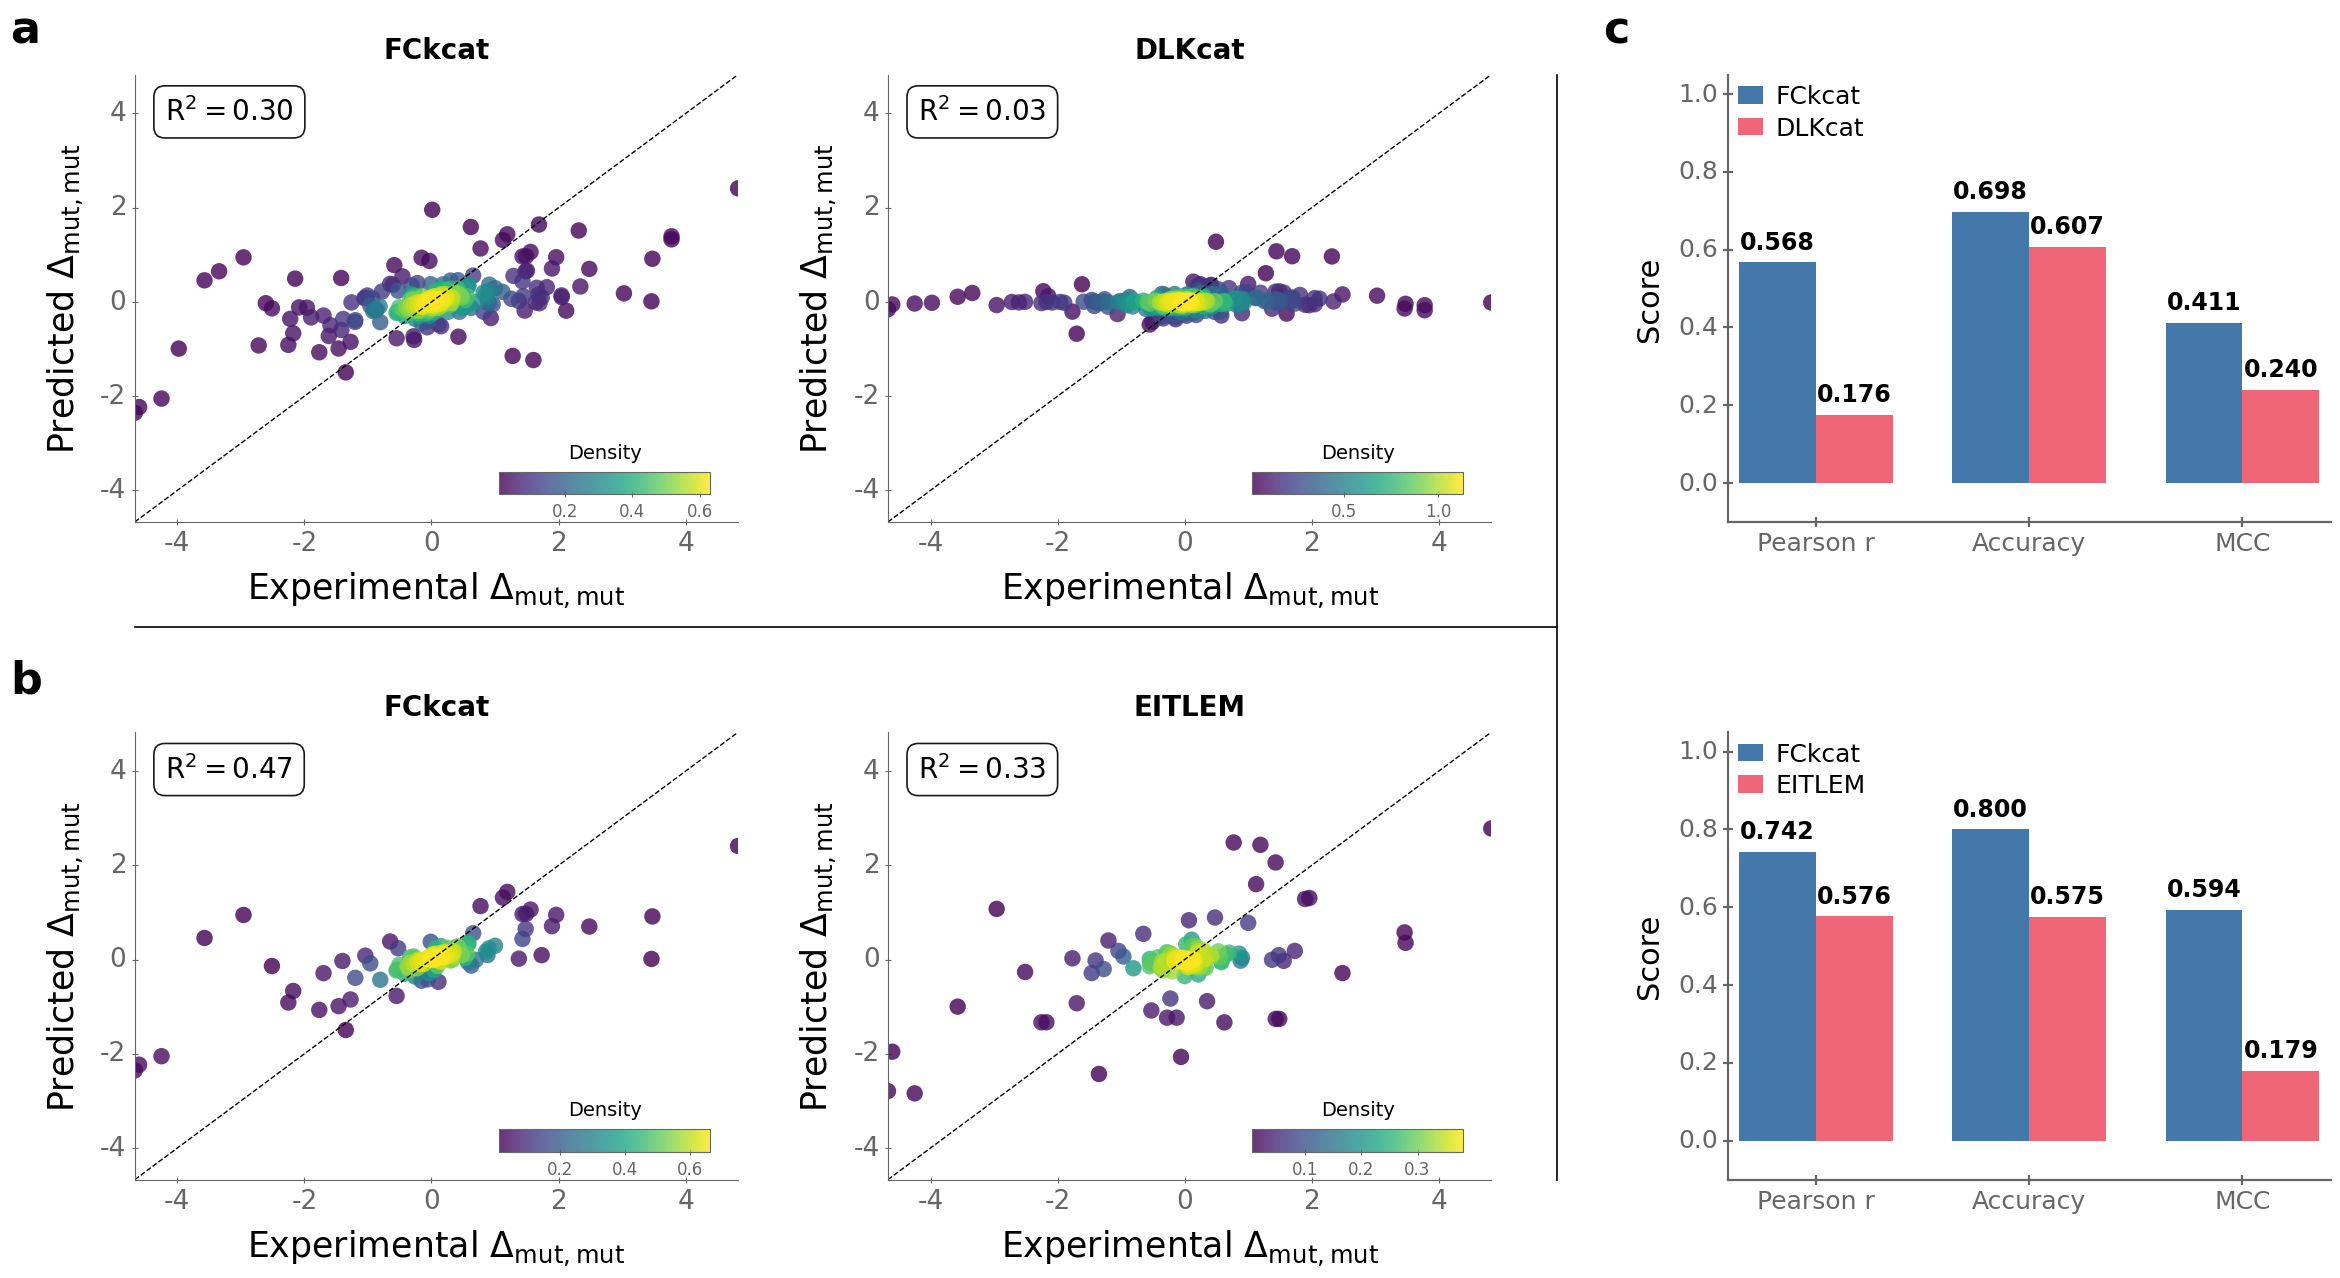

In [31]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")

###################################################
# Figure
#   A = top-left + top-mid
#   B = bottom-left + bottom-mid
#   C = right column
###################################################


fig, axes = plt.subplots(2, 3, figsize=(24, 13))

xlab_delta = r"Experimental $\Delta_{\mathrm{mut,mut}}$"
ylab_delta = r"Predicted $\Delta_{\mathrm{mut,mut}}$"

# Row 1 DLKcat
_sc11 = utils_helpers._scatter_panel(
    axes[0, 0],
    df_test_unseen_dlkcat_mutmut['delta_log_kcat'],
    df_test_unseen_dlkcat_mutmut['collective_prediction'],
    title="FCkcat",
    x_label=xlab_delta,
    y_label=ylab_delta
)

_sc12 = utils_helpers._scatter_panel(
    axes[0, 1],
    df_test_unseen_dlkcat_mutmut['delta_log_kcat'],
    df_test_unseen_dlkcat_mutmut['delta_dlkcat'],
    title="DLKcat",
    x_label=xlab_delta,
    y_label=ylab_delta
)

utils_helpers._bars_panel(
    axes[0, 2],
    df_test_unseen_dlkcat_mutmut,
    true_col='delta_log_kcat',
    pred_cols=['collective_prediction', 'delta_dlkcat'],
    labels=['FCkcat', 'DLKcat'],
    title=""
)

# Row 2 EITLEM
_sc21 = utils_helpers._scatter_panel(
    axes[1, 0],
    df_test_unseen_eitlem_mutmut['delta_log_kcat'],
    df_test_unseen_eitlem_mutmut['collective_prediction'],
    title="FCkcat",
    x_label=xlab_delta,
    y_label=ylab_delta
)

_sc22 = utils_helpers._scatter_panel(
    axes[1, 1],
    df_test_unseen_eitlem_mutmut['delta_log_kcat'],
    df_test_unseen_eitlem_mutmut['delta_eitlem'],
    title="EITLEM",
    x_label=xlab_delta,
    y_label=ylab_delta
)

utils_helpers._bars_panel(
    axes[1, 2],
    df_test_unseen_eitlem_mutmut,
    true_col='delta_log_kcat',
    pred_cols=['collective_prediction', 'delta_eitlem'],
    labels=['FCkcat', 'EITLEM'],
    title=""
)


# Texte global
for ax in axes.ravel():
    ax.xaxis.label.set_size(21)
    ax.yaxis.label.set_size(21)
    ax.title.set_size(20)
    ax.tick_params(axis='both', which='major', labelsize=17)

    for txt in ax.texts:
        current = txt.get_fontsize()
        txt.set_fontsize(max(current, 16))


for ax in [axes[0, 2], axes[1, 2]]:
    ax.yaxis.label.set_size(22)
    ax.tick_params(axis='both', which='major', labelsize=18)
    for txt in ax.texts:
        txt.set_fontsize(max(txt.get_fontsize(), 17))


for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]:
    ax.xaxis.label.set_size(25)
    ax.yaxis.label.set_size(25)
    ax.tick_params(axis='both', which='major', labelsize=19)
    ax.tick_params(axis='both', which='minor', labelsize=17)


for ax in [axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]]:
    for coll in ax.collections:
        if hasattr(coll, "get_sizes") and hasattr(coll, "set_sizes"):
            sizes = coll.get_sizes()
            if sizes is not None and len(sizes) > 0:
                coll.set_sizes(sizes * 2.0)


# Espacement entre panneaux
fig.subplots_adjust(
    left=0.07,
    right=0.985,
    bottom=0.08,
    top=0.93,
    wspace=0.32,
    hspace=0.47
)

fig.canvas.draw()

shift_left = 0.018
for ax in [axes[0, 1], axes[1, 1]]:
    pos = ax.get_position()
    ax.set_position([pos.x0 - shift_left, pos.y0, pos.width, pos.height])

fig.canvas.draw()


# Délimitations A / B / C
gap_left = axes[0, 1].get_position().x1
gap_right = axes[0, 2].get_position().x0
x_sep = gap_left + 0.28 * (gap_right - gap_left)
y_sep = (axes[0, 0].get_position().y0 + axes[1, 0].get_position().y1) / 2

left_bound = min(ax.get_position().x0 for ax in axes.ravel())
right_bound = max(ax.get_position().x1 for ax in axes.ravel())
bottom_bound = min(ax.get_position().y0 for ax in axes.ravel())
top_bound = max(ax.get_position().y1 for ax in axes.ravel())

fig.add_artist(Line2D(
    [x_sep, x_sep], [bottom_bound, top_bound],
    transform=fig.transFigure, color='black', linewidth=1.2
))

fig.add_artist(Line2D(
    [left_bound, x_sep], [y_sep, y_sep],
    transform=fig.transFigure, color='black', linewidth=1.2
))


fig.text(
    axes[0, 0].get_position().x0 - 0.052,
    top_bound + 0.024,
    'a',
    fontsize=32,
    fontweight='bold'
)

fig.text(
    axes[1, 0].get_position().x0 - 0.052,
    axes[1, 0].get_position().y1 + 0.030,
    'b',
    fontsize=32,
    fontweight='bold'
)

fig.text(
    axes[0, 2].get_position().x0 - 0.052,
    top_bound + 0.024,
    'c',
    fontsize=32,
    fontweight='bold'
)

plt.show()

## 2. Reproduction of Fig S5

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
from Bio.Align import PairwiseAligner
from collections import defaultdict
from tqdm.auto import tqdm
from rapidfuzz import process, fuzz


df_kcat_eitlem = pd.read_json(Path("..") / "data" / "EITLEM_data" / "kcat_data.json")
df_kcat_all = pd.read_pickle(Path("..") / "data" / "datasets" / "df_kcat_final.pkl")

In [33]:
# keep only usable rows 
df = df_kcat_all[['Identifier', 'Sequence_new']].dropna().copy()
df['Sequence_new'] = df['Sequence_new'].astype(str)

# optional: remove exact duplicate sequences within the same Identifier
df = df.drop_duplicates(subset=['Identifier', 'Sequence_new'])

# global aligner setup
aligner = PairwiseAligner()
aligner.mode = "global"
aligner.match_score = 1
aligner.mismatch_score = 0
aligner.open_gap_score = -1
aligner.extend_gap_score = -0.5

def sequence_identity(seq1, seq2):
    """
    Pairwise identity = identical aligned positions / alignment length
    """
    alignment = aligner.align(seq1, seq2)[0]
    
    s1 = alignment[0]
    s2 = alignment[1]
    
    matches = sum(a == b for a, b in zip(s1, s2) if a != '-' and b != '-')
    aln_len = len(s1)
    
    return matches / aln_len if aln_len > 0 else np.nan

# compute all within-Identifier pairs
results = []

for identifier, group in df.groupby('Identifier'):
    seqs = group['Sequence_new'].tolist()
    
    # all unique pairs inside the same Identifier
    for seq1, seq2 in combinations(seqs, 2):
        sim = sequence_identity(seq1, seq2)
        results.append({
            'Identifier': identifier,
            'seq1': seq1,
            'seq2': seq2,
            'similarity': sim
        })

df_similarity = pd.DataFrame(results)

print(df_similarity.head())
print(f"Number of pairs: {len(df_similarity)}")

   Identifier                                               seq1  \
0           0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...   
1           0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...   
2           0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...   
3           0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...   
4           0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...   

                                                seq2  similarity  
0  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...    0.998162  
1  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...    0.998162  
2  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...    0.998162  
3  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...    0.998162  
4  MSKKIHVVGHRNPDTDSICAAIAYARLKQRLGMDHVIPYRAGKINR...    0.998162  
Number of pairs: 38424


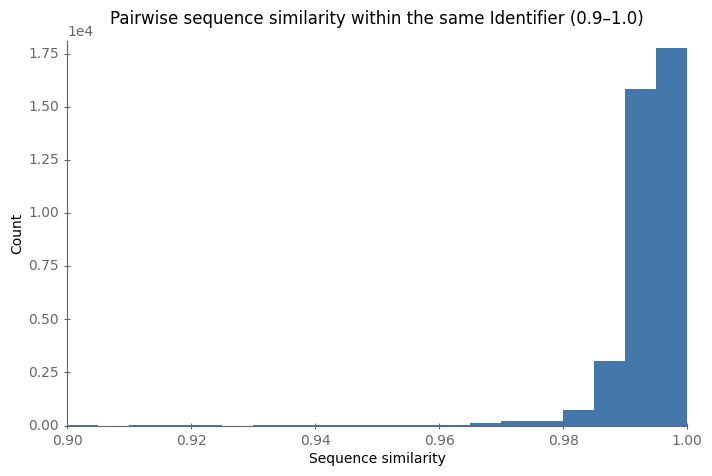

In [34]:
zoom = df_similarity['similarity'].dropna()
zoom = zoom[(zoom >= 0.9) & (zoom <= 1.0)]

plt.figure(figsize=(8, 5))
plt.hist(zoom, bins=np.linspace(0.9, 1.0, 21))
plt.xlim(0.9, 1.0)
plt.xlabel('Sequence similarity')
plt.ylabel('Count')
plt.title('Pairwise sequence similarity within the same Identifier (0.9–1.0)')
plt.show()

#### Cluster EITLEM and DLkcat

In [35]:
df_kcat_eitlem = pd.read_json(Path("..") / "data" / "EITLEM_data" / "kcat_data.json")
df_kcat_dlkcat = pd.read_json(Path("..") / "data" / "DLKcat_data" / "Kcat_combination_0918_wildtype_mutant.json")
df_kcat_fckcat = pd.read_pickle(Path("..") / "data" / "datasets" / "df_kcat_final.pkl")


In [36]:
df_kcat_dlkcat_grp, dlkcat_seq_to_group, dlkcat_group_to_rep = cluster_sequences_in_df(
    df_kcat_dlkcat,
    seq_col='Sequence',
    threshold=0.98,
    method='identity',
    progress=True
)

df_kcat_eitlem_grp, eitlem_seq_to_group, eitlem_group_to_rep = cluster_sequences_in_df(
    df_kcat_eitlem,
    seq_col='sequence',
    threshold=0.98,
    method='identity',
    progress=True
)

Rows in dataframe: 17,010
Non-null sequences: 17,010
Unique sequences: 7,857


Clustering Sequence:   0%|          | 0/7857 [00:00<?, ?it/s]

Number of groups created: 3,238
Rows in dataframe: 35,147
Non-null sequences: 35,147
Unique sequences: 15,109


Clustering sequence:   0%|          | 0/15109 [00:00<?, ?it/s]

Number of groups created: 6,775


In [37]:
df_kcat_eitlem_grp['geom_kcat_log10'] = df_kcat_eitlem_grp['value'].apply(lambda x: np.log10(x))

/tmp/ipykernel_258582/1889987242.py:1: RuntimeWarning: divide by zero encountered in log10
  df_kcat_eitlem_grp['geom_kcat_log10'] = df_kcat_eitlem_grp['value'].apply(lambda x: np.log10(x))


In [38]:
import numpy as np

df = df_kcat_eitlem_grp[['Identifier_098', 'geom_kcat_log10']].copy()

print("NaN in y:", df['geom_kcat_log10'].isna().sum())
print("Finite y:", np.isfinite(df['geom_kcat_log10']).sum())
print("Non-finite y:", (~np.isfinite(df['geom_kcat_log10'])).sum())

print(df.loc[~np.isfinite(df['geom_kcat_log10']), 'geom_kcat_log10'].head())

NaN in y: 0
Finite y: 35143
Non-finite y: 4
30877   -inf
33171   -inf
33746   -inf
35054   -inf
Name: geom_kcat_log10, dtype: float64


In [39]:
df = df_kcat_eitlem_grp[['Identifier_098', 'geom_kcat_log10']].copy()
df = df[np.isfinite(df['geom_kcat_log10'])].copy()
df['Identifier_098'] = df['Identifier_098'].astype(str)

group_sizes = df.groupby("Identifier_098")["Identifier_098"].transform("size")
df = df[group_sizes > 1].copy()

In [40]:
import statsmodels.formula.api as smf

model = smf.mixedlm("geom_kcat_log10 ~ 1", data=df, groups=df["Identifier_098"])
result = model.fit(reml=True, method="lbfgs")

group_var = result.cov_re.iloc[0, 0]
resid_var = result.scale
icc = group_var / (group_var + resid_var)

print(result.summary())
print(f"Group variance: {group_var:.4f}")
print(f"Residual variance: {resid_var:.4f}")
print(f"ICC: {icc:.4f}")
print(f"Percent variance due to group: {100*icc:.2f}%")

            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: geom_kcat_log10
No. Observations: 33058   Method:             REML           
No. Groups:       4690    Scale:              0.7798         
Min. group size:  2       Log-Likelihood:     -48413.5894    
Max. group size:  161     Converged:          Yes            
Mean group size:  7.0                                        
---------------------------------------------------------------
            Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------
Intercept   0.557      0.020   27.855   0.000    0.518    0.596
Group Var   1.663      0.047                                   

Group variance: 1.6632
Residual variance: 0.7798
ICC: 0.6808
Percent variance due to group: 68.08%


In [41]:

import pandas as pd
import statsmodels.formula.api as smf

def compute_delta_kcat_cluster(
    df,
    id_col="Identifier_098",
    type_col="Type",              
    value_col="geom_kcat_log10",
    wt_label="wildtype"
):
    df = df.copy()

    # clean type column
    df["_type_clean"] = df[type_col].astype(str).str.strip().str.lower()

    # keep only finite response values
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])].copy()

    # wildtype mean per cluster
    wt_map = (
        df.loc[df["_type_clean"] == wt_label, [id_col, value_col]]
          .groupby(id_col)[value_col]
          .mean()
    )

    # map WT value back to every row in the same cluster
    df["wt_geom_kcat_log10"] = df[id_col].map(wt_map)

    # delta = observed - WT
    df["delta"] = df[value_col] - df["wt_geom_kcat_log10"]

    return df


df_kcat_eitlem_delta = compute_delta_kcat_cluster(
    df_kcat_eitlem_grp,
    id_col="Identifier_098",
    type_col="type",   
    value_col="geom_kcat_log10",
    wt_label="wild"
)


type_col = "type"   

df_kcat_eitlem_delta["_type_clean"] = (
    df_kcat_eitlem_delta[type_col].astype(str).str.strip().str.lower()
)

df_kcat_eitlem_delta_model = df_kcat_eitlem_delta[
    (df_kcat_eitlem_delta["_type_clean"] != "wild") &
    (np.isfinite(df_kcat_eitlem_delta["delta"]))
].copy()

model_delta = smf.mixedlm(
    "delta ~ 1",
    data=df_kcat_eitlem_delta_model,
    groups=df_kcat_eitlem_delta_model["Identifier_098"]
)

result_delta = model_delta.fit(reml=True, method="lbfgs")

group_var = float(result_delta.cov_re.iloc[0, 0])
resid_var = float(result_delta.scale)
icc = group_var / (group_var + resid_var)

print(result_delta.summary())
print(f"Group variance: {group_var:.4f}")
print(f"Residual variance: {resid_var:.4f}")
print(f"ICC: {icc:.4f}")
print(f"Percent variance due to group: {100*icc:.2f}%")

          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta      
No. Observations: 14042   Method:             REML       
No. Groups:       1456    Scale:              0.7882     
Min. group size:  1       Log-Likelihood:     -19686.9344
Max. group size:  159     Converged:          Yes        
Mean group size:  9.6                                    
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     -0.678    0.027 -25.319 0.000 -0.730 -0.625
Group Var      0.839    0.045                            

Group variance: 0.8389
Residual variance: 0.7882
ICC: 0.5156
Percent variance due to group: 51.56%



Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


between_group: [1.66316258 0.83889215]
within_group: [0.77978433 0.78820589]


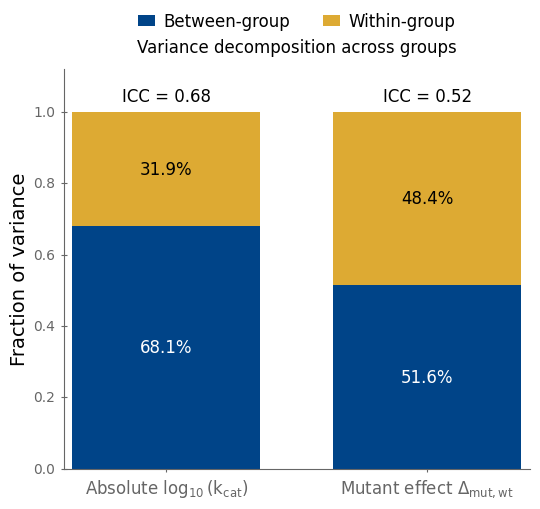

In [42]:
import matplotlib.pyplot as plt

def plot_variance_decomposition(between_group, within_group, labels, ax=None, fontsize=12):
    """Stacked bar chart of between/within group variance fractions with ICC annotations."""
    high_contrast = ['#004488', '#DDAA33', '#BB5566', '#000000']
    total         = between_group + within_group
    between_frac  = between_group / total
    within_frac   = within_group  / total
    icc           = between_frac

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5.2))
    else:
        fig = ax.get_figure()

    x = np.arange(len(labels))
    width = 0.72
    ax.bar(x, between_frac, width=width, color=high_contrast[0], label='Between-group')
    ax.bar(x, within_frac,  width=width, bottom=between_frac, color=high_contrast[1], label='Within-group')

    for i in range(len(labels)):
        ax.text(x[i], between_frac[i] / 2,
                f'{100*between_frac[i]:.1f}%', ha='center', va='center',
                color='white', fontsize=fontsize)
        ax.text(x[i], between_frac[i] + within_frac[i] / 2,
                f'{100*within_frac[i]:.1f}%', ha='center', va='center',
                color='black', fontsize=fontsize)
        ax.text(x[i], 1.02, f'ICC = {icc[i]:.2f}',
                ha='center', va='bottom', fontsize=fontsize)

    ax.set_ylabel('Fraction of variance', fontsize=fontsize + 2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.08), ncol=2,
              fontsize=fontsize)
    return fig, ax

import matplotlib.pyplot as plt
plt.style.use('utils/CCB_plot_style_0v4.mplstyle')


labels = [
    r'Absolute $\log_{10}(k_{\mathrm{cat}})$',
    r'Mutant effect $\Delta_{\mathrm{mut,wt}}$'
]

between_group = np.array([
    float(result.cov_re.iloc[0, 0]),
    float(result_delta.cov_re.iloc[0, 0])
])

within_group = np.array([
    float(result.scale),
    float(result_delta.scale)
])

print("between_group:", between_group)
print("within_group:", within_group)

fig, ax = plot_variance_decomposition(
    between_group=between_group,
    within_group=within_group,
    labels=labels
)

ax.set_title(r'Variance decomposition across groups')
plt.tight_layout()
plt.show()

In [43]:
import numpy as np
import pandas as pd

def summarize_mixedlm(result, dataset, outcome):
    between_group = float(result.cov_re.iloc[0, 0])
    within_group  = float(result.scale)
    icc = between_group / (between_group + within_group)

    return {
        "dataset": dataset,
        "outcome": outcome,
        "between_group": between_group,
        "within_group": within_group,
        "icc": icc,
        "between_pct": 100 * icc,
        "within_pct": 100 * (1 - icc),
    }

In [44]:
variance_rows = []

variance_rows.append(
    summarize_mixedlm(
        result,
        dataset="Eitlem",
        outcome="absolute"
    )
)

variance_rows.append(
    summarize_mixedlm(
        result_delta,
        dataset="Eitlem",
        outcome="delta"
    )
)

variance_df = pd.DataFrame(variance_rows)
variance_df

,dataset,outcome,between_group,within_group,icc,between_pct,within_pct
0,Eitlem,absolute,1.663163,0.779784,0.680802,68.080177,31.919823
1,Eitlem,delta,0.838892,0.788206,0.515576,51.557566,48.442434



Bad key text.latex.preview in file utils/CCB_plot_style_0v4.mplstyle, line 55 ('text.latex.preview  : False')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution

Bad key mathtext.fallback_to_cm in file utils/CCB_plot_style_0v4.mplstyle, line 63 ('mathtext.fallback_to_cm : True ## When True, use symbols from the Computer Modern fonts')
You probably need to get an updated matplotlibrc file from
https://github.com/matplotlib/matplotlib/blob/v3.10.9/lib/matplotlib/mpl-data/matplotlibrc
or from the matplotlib source distribution


NaN in y: 6
Finite y: 17004
Non-finite y: 6
12434   NaN
12637   NaN
12638   NaN
14857   NaN
15454   NaN
Name: geom_kcat_log10, dtype: float64
            Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: geom_kcat_log10
No. Observations: 15876   Method:             REML           
No. Groups:       2110    Scale:              0.8913         
Min. group size:  2       Log-Likelihood:     -23950.4035    
Max. group size:  161     Converged:          Yes            
Mean group size:  7.5                                        
---------------------------------------------------------------
            Coef.   Std.Err.     z      P>|z|   [0.025   0.975]
---------------------------------------------------------------
Intercept   0.664      0.028   23.443   0.000    0.609    0.720
Group Var   1.461      0.059                                   

Group variance: 1.4609
Residual variance: 0.8913
ICC: 0.6211
Percent variance due to group: 62.11%
Rows for delta m

/home/yvan/miniconda3/envs/FCKcat_env/lib/python3.11/site-packages/statsmodels/regression/mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)


          Mixed Linear Model Regression Results
Model:            MixedLM Dependent Variable: delta      
No. Observations: 7332    Method:             REML       
No. Groups:       776     Scale:              0.8720     
Min. group size:  1       Log-Likelihood:     -10622.7889
Max. group size:  159     Converged:          Yes        
Mean group size:  9.4                                    
---------------------------------------------------------
              Coef.  Std.Err.    z    P>|z| [0.025 0.975]
---------------------------------------------------------
Intercept     -0.880    0.037 -23.811 0.000 -0.952 -0.807
Group Var      0.828    0.060                            

Group variance: 0.8276
Residual variance: 0.8720
ICC: 0.4870
Percent variance due to group: 48.70%
between_group: [1.46090517 0.82762726]
within_group: [0.89132568 0.871975  ]


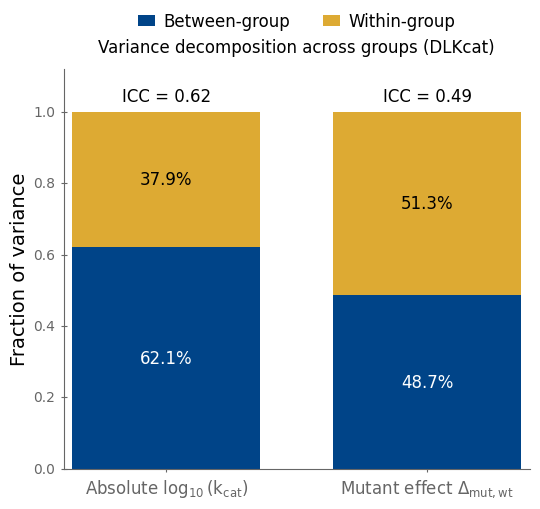

  dataset   outcome  between_group  within_group       icc  between_pct  \
0  DLKcat  absolute       1.460905      0.891326  0.621072    62.107219   
1  DLKcat     delta       0.827627      0.871975  0.486953    48.695349   

   within_pct  
0   37.892781  
1   51.304651  


In [45]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
plt.style.use(Path("utils") / "CCB_plot_style_0v4.mplstyle")


# 0. prepare DLKcat data
df_kcat_dlkcat_grp = df_kcat_dlkcat_grp.copy()

# safer log10: non-positive values become NaN
df_kcat_dlkcat_grp["geom_kcat_log10"] = pd.to_numeric(
    df_kcat_dlkcat_grp["Value"], errors="coerce"
)
df_kcat_dlkcat_grp.loc[df_kcat_dlkcat_grp["geom_kcat_log10"] <= 0, "geom_kcat_log10"] = np.nan
df_kcat_dlkcat_grp["geom_kcat_log10"] = np.log10(df_kcat_dlkcat_grp["geom_kcat_log10"])



# 1. absolute model
df_abs_dlkcat = df_kcat_dlkcat_grp[["Identifier_098", "geom_kcat_log10"]].copy()

print("NaN in y:", df_abs_dlkcat["geom_kcat_log10"].isna().sum())
print("Finite y:", np.isfinite(df_abs_dlkcat["geom_kcat_log10"]).sum())
print("Non-finite y:", (~np.isfinite(df_abs_dlkcat["geom_kcat_log10"])).sum())

print(df_abs_dlkcat.loc[~np.isfinite(df_abs_dlkcat["geom_kcat_log10"]), "geom_kcat_log10"].head())

df_abs_dlkcat = df_abs_dlkcat[np.isfinite(df_abs_dlkcat["geom_kcat_log10"])].copy()
df_abs_dlkcat["Identifier_098"] = df_abs_dlkcat["Identifier_098"].astype(str)

group_sizes = df_abs_dlkcat.groupby("Identifier_098")["Identifier_098"].transform("size")
df_abs_dlkcat = df_abs_dlkcat[group_sizes > 1].copy()

model_dlkcat = smf.mixedlm(
    "geom_kcat_log10 ~ 1",
    data=df_abs_dlkcat,
    groups=df_abs_dlkcat["Identifier_098"]
)
result_dlkcat = model_dlkcat.fit(reml=True, method="lbfgs")

group_var_dlkcat = float(result_dlkcat.cov_re.iloc[0, 0])
resid_var_dlkcat = float(result_dlkcat.scale)
icc_dlkcat = group_var_dlkcat / (group_var_dlkcat + resid_var_dlkcat)

print(result_dlkcat.summary())
print(f"Group variance: {group_var_dlkcat:.4f}")
print(f"Residual variance: {resid_var_dlkcat:.4f}")
print(f"ICC: {icc_dlkcat:.4f}")
print(f"Percent variance due to group: {100*icc_dlkcat:.2f}%")



# 2. helper for delta vs wildtype
def compute_delta_kcat_cluster(
    df,
    id_col="Identifier_098",
    type_col="Type",
    value_col="geom_kcat_log10",
    wt_label="wildtype"
):
    df = df.copy()

    df["_type_clean"] = df[type_col].astype(str).str.strip().str.lower()
    df[value_col] = pd.to_numeric(df[value_col], errors="coerce")
    df = df[np.isfinite(df[value_col])].copy()

    wt_map = (
        df.loc[df["_type_clean"] == wt_label, [id_col, value_col]]
          .groupby(id_col)[value_col]
          .mean()
    )

    df["wt_geom_kcat_log10"] = df[id_col].map(wt_map)
    df["delta"] = df[value_col] - df["wt_geom_kcat_log10"]

    return df


# 3. delta model
df_kcat_dlkcat_delta = compute_delta_kcat_cluster(
    df_kcat_dlkcat_grp,
    id_col="Identifier_098",
    type_col="Type",
    value_col="geom_kcat_log10",
    wt_label="wildtype"
)

df_kcat_dlkcat_delta["_type_clean"] = (
    df_kcat_dlkcat_delta["Type"].astype(str).str.strip().str.lower()
)

df_kcat_dlkcat_delta_model = df_kcat_dlkcat_delta[
    (df_kcat_dlkcat_delta["_type_clean"] != "wildtype") &
    (np.isfinite(df_kcat_dlkcat_delta["delta"]))
].copy()

print("Rows for delta model:", len(df_kcat_dlkcat_delta_model))
print("Groups for delta model:", df_kcat_dlkcat_delta_model["Identifier_098"].nunique())

model_dlkcat_delta = smf.mixedlm(
    "delta ~ 1",
    data=df_kcat_dlkcat_delta_model,
    groups=df_kcat_dlkcat_delta_model["Identifier_098"]
)
result_dlkcat_delta = model_dlkcat_delta.fit(reml=True, method="lbfgs")

group_var_dlkcat_delta = float(result_dlkcat_delta.cov_re.iloc[0, 0])
resid_var_dlkcat_delta = float(result_dlkcat_delta.scale)
icc_dlkcat_delta = group_var_dlkcat_delta / (group_var_dlkcat_delta + resid_var_dlkcat_delta)

print(result_dlkcat_delta.summary())
print(f"Group variance: {group_var_dlkcat_delta:.4f}")
print(f"Residual variance: {resid_var_dlkcat_delta:.4f}")
print(f"ICC: {icc_dlkcat_delta:.4f}")
print(f"Percent variance due to group: {100*icc_dlkcat_delta:.2f}%")


# 4. plotting helper
def plot_variance_decomposition(between_group, within_group, labels, ax=None, fontsize=12):
    high_contrast = ['#004488', '#DDAA33', '#BB5566', '#000000']
    total = between_group + within_group
    between_frac = between_group / total
    within_frac = within_group / total
    icc = between_frac

    if ax is None:
        fig, ax = plt.subplots(figsize=(5.5, 5.2))
    else:
        fig = ax.get_figure()

    x = np.arange(len(labels))
    width = 0.72
    ax.bar(x, between_frac, width=width, color=high_contrast[0], label='Between-group')
    ax.bar(x, within_frac, width=width, bottom=between_frac, color=high_contrast[1], label='Within-group')

    for i in range(len(labels)):
        ax.text(x[i], between_frac[i] / 2,
                f'{100*between_frac[i]:.1f}%', ha='center', va='center',
                color='white', fontsize=fontsize)
        ax.text(x[i], between_frac[i] + within_frac[i] / 2,
                f'{100*within_frac[i]:.1f}%', ha='center', va='center',
                color='black', fontsize=fontsize)
        ax.text(x[i], 1.02, f'ICC = {icc[i]:.2f}',
                ha='center', va='bottom', fontsize=fontsize)

    ax.set_ylabel('Fraction of variance', fontsize=fontsize + 2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=fontsize)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.legend(frameon=False, loc='lower center', bbox_to_anchor=(0.5, 1.08), ncol=2,
              fontsize=fontsize)
    return fig, ax


# 5. single DLKcat plot
labels = [
    r'Absolute $\log_{10}(k_{\mathrm{cat}})$',
    r'Mutant effect $\Delta_{\mathrm{mut,wt}}$'
]

between_group = np.array([
    float(result_dlkcat.cov_re.iloc[0, 0]),
    float(result_dlkcat_delta.cov_re.iloc[0, 0])
])

within_group = np.array([
    float(result_dlkcat.scale),
    float(result_dlkcat_delta.scale)
])

print("between_group:", between_group)
print("within_group:", within_group)

fig, ax = plot_variance_decomposition(
    between_group=between_group,
    within_group=within_group,
    labels=labels
)

ax.set_title(r'Variance decomposition across groups (DLKcat)')
plt.tight_layout()
plt.show()


# 6. save summary for later 3-panel figure
def summarize_mixedlm(result, dataset, outcome):
    between_group = float(result.cov_re.iloc[0, 0])
    within_group = float(result.scale)
    icc = between_group / (between_group + within_group)

    return {
        "dataset": dataset,
        "outcome": outcome,
        "between_group": between_group,
        "within_group": within_group,
        "icc": icc,
        "between_pct": 100 * icc,
        "within_pct": 100 * (1 - icc),
    }

variance_rows = []

variance_rows.append(
    summarize_mixedlm(
        result_dlkcat,
        dataset="DLKcat",
        outcome="absolute"
    )
)

variance_rows.append(
    summarize_mixedlm(
        result_dlkcat_delta,
        dataset="DLKcat",
        outcome="delta"
    )
)

variance_df_dlkcat = pd.DataFrame(variance_rows)
print(variance_df_dlkcat)

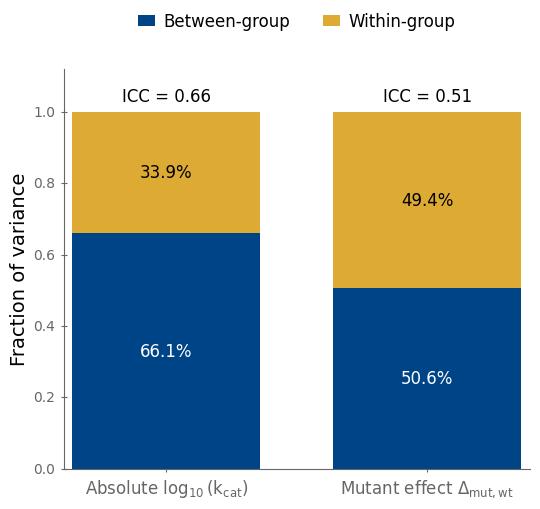

In [46]:
labels = [
    r'Absolute $\log_{10}(k_{\mathrm{cat}})$',
    r'Mutant effect $\Delta_{\mathrm{mut,wt}}$'
]
between_group = np.array([1.6032, 0.7662070490919531])
within_group  = np.array([0.8220, 0.7490436048236873])

fig, ax = plot_variance_decomposition(between_group, within_group, labels)
plt.tight_layout()
plt.show()

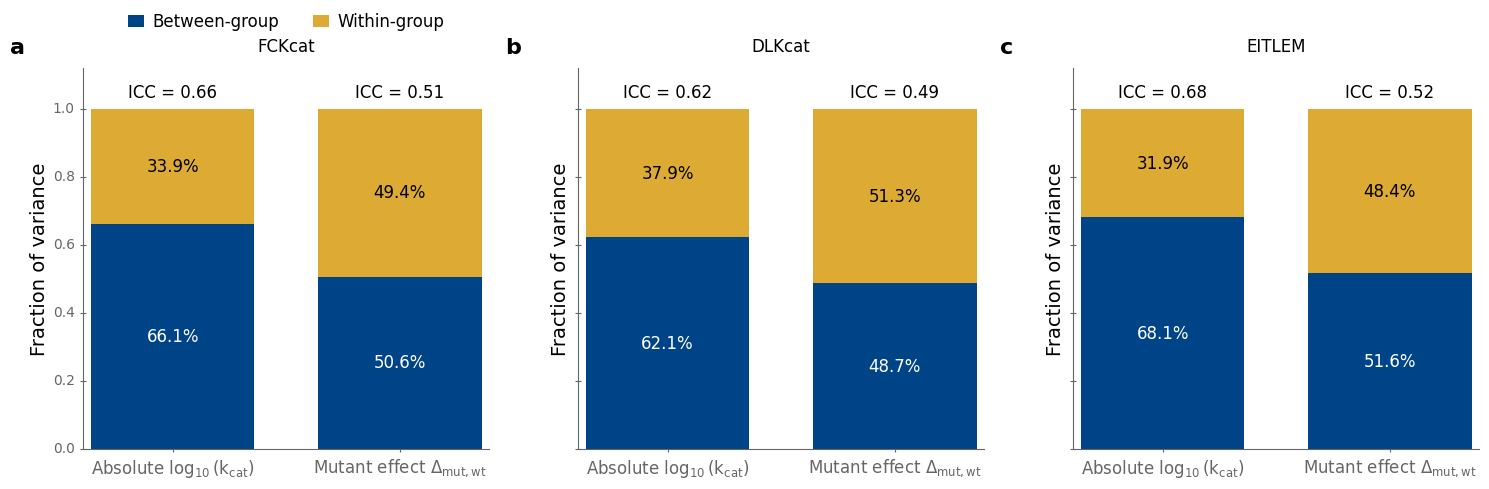

In [47]:
import numpy as np
import matplotlib.pyplot as plt


labels = [
    r'Absolute $\log_{10}(k_{\mathrm{cat}})$',
    r'Mutant effect $\Delta_{\mathrm{mut,wt}}$'
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

# A: FCKcat
between_group_fckcat = np.array([1.6032, 0.7662070490919531])
within_group_fckcat  = np.array([0.8220, 0.7490436048236873])

plot_variance_decomposition(
    between_group_fckcat,
    within_group_fckcat,
    labels,
    ax=axes[0]
)
axes[0].set_title("FCKcat")
axes[0].text(-0.18, 1.08, "a", transform=axes[0].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")


# B: DLKcat
between_group_dlkcat = np.array([
    float(result_dlkcat.cov_re.iloc[0, 0]),
    float(result_dlkcat_delta.cov_re.iloc[0, 0])
])

within_group_dlkcat = np.array([
    float(result_dlkcat.scale),
    float(result_dlkcat_delta.scale)
])

plot_variance_decomposition(
    between_group_dlkcat,
    within_group_dlkcat,
    labels,
    ax=axes[1]
)
axes[1].set_title("DLKcat")
axes[1].text(-0.18, 1.08, "b", transform=axes[1].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")

# C: Eitlem
between_group_eitlem = np.array([
    float(result.cov_re.iloc[0, 0]),
    float(result_delta.cov_re.iloc[0, 0])
])

within_group_eitlem = np.array([
    float(result.scale),
    float(result_delta.scale)
])

plot_variance_decomposition(
    between_group_eitlem,
    within_group_eitlem,
    labels,
    ax=axes[2]
)
axes[2].set_title("EITLEM")
axes[2].text(-0.18, 1.08, "c", transform=axes[2].transAxes,
             fontsize=16, fontweight="bold", va="top", ha="left")

# keep only one legend
for ax in axes[1:]:
    leg = ax.get_legend()
    if leg is not None:
        leg.remove()

plt.tight_layout()
plt.show()